# Ignition: Chicken-and-Egg, Lock-In, and Tipping

> Computational Analysis of Social Complexity
>
> Fall 2026, Spencer Lyon

**Prerequisites**

- L11.01
- Game theory (week 8)
- ABM concepts (week 6)
- Graphs (week 3)

**Outcomes**

- Model the chicken-and-egg problem as a coordination game with multiple equilibria
- Simulate increasing-returns adoption and explain lock-in and path dependence
- Analyze threshold adoption on networks and identify tipping conditions
- Evaluate when winner-take-all does and does not apply

**References**

- [Easley & Kleinberg, Chapter 19: Cascading Behavior in Networks](https://www.cs.cornell.edu/home/kleinber/networks-book/networks-book.pdf) (required)
- Arthur (1989), *Competing Technologies, Increasing Returns, and Lock-In by Historical Events*
- *Matchmakers* (Evans & Schmalensee, 2016), Chapter 5 (optional extra reading)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import quantecon.game_theory as gt

## Two Platforms Walk into a Market

- OpenTable launched in 1998 with a problem
  - Diners would not visit a reservation platform with no restaurants
  - Restaurants would not buy into a platform with no diners
- Its response was intensely local
  - Install reservation terminals in San Francisco restaurants
  - Make the service free for diners
  - Build enough density in one city, then repeat
- OpenTable ignited

### A Second Story

- Windows Phone launched in 2010
- Microsoft spent billions and reviewers praised much of the hardware
- But users asked: where are the apps?
- Developers asked: where are the users?
- No apps $\rightarrow$ no users $\rightarrow$ no apps
- By 2017, the platform was effectively dead

### The Tension

- Same **chicken-and-egg problem**
- Opposite outcomes
- Recall from L11.01:
  - **Same-side network effects** connect participants on one side
  - **Cross-side network effects** connect activity across sides
- What separates ignite from fizzle?
- Today we study three answers: equilibrium selection, increasing returns, and network structure

## Build 1: Chicken-and-Egg as a Game

- Let the two players be Restaurants and Diners
- Each chooses one action: `Join` or `Stay out`
- Joining together creates value for both sides
- Joining alone is costly
- Staying out is safe, but produces no platform value
- Before calculating anything: what outcomes seem self-reinforcing?

### Payoffs

- Rows are the Restaurant's action: `Join`, then `Stay out`
- Columns are the Diner's action: `Join`, then `Stay out`
- Each cell reports `(Restaurant, Diner)`

$$
\begin{array}{c|cc}
 & \text{Diner: Join} & \text{Diner: Stay\ out} \\
\hline
\text{Restaurant: Join} & (3,3) & (-2,0) \\
\text{Restaurant: Stay\ out} & (0,-2) & (0,0)
\end{array}
$$

- The numbers are illustrative; their ordering carries the economics

In [2]:
restaurant_payoffs = np.array([[3, -2], [0, 0]])
diner_payoffs = np.array([[3, -2], [0, 0]])

restaurant = gt.Player(restaurant_payoffs)
diner = gt.Player(diner_payoffs)
platform_game = gt.NormalFormGame([restaurant, diner])

### Recall from Week 8: Use Best Responses

- If Diners join, the Restaurant's best response is to join: $3 > 0$
- If Diners stay out, the Restaurant's best response is to stay out: $0 > -2$
- The Diner faces the same logic
- A Nash equilibrium is an action profile in which both actions are best responses
- Question: can there be more than one?

In [3]:
coordination_equilibria = gt.pure_nash_brute(platform_game)

[{"actions": eq, "payoffs": platform_game[eq]} for eq in coordination_equilibria]

[{'actions': (0, 0), 'payoffs': array([3, 3])},
 {'actions': (1, 1), 'payoffs': array([0, 0])}]

### Reveal: The Bad Outcome Is Also an Equilibrium

- `(Join, Join)` is a Nash equilibrium
- `(Stay out, Stay out)` is also a Nash equilibrium
- At the bad equilibrium, neither side wants to join alone
- The good equilibrium is Pareto-superior, but that does not make beliefs coordinate on it
- A platform's first job is therefore **equilibrium selection**
- **Critical mass** is the participation level beyond which joining becomes self-sustaining

### Divide and Conquer

- Suppose the platform subsidizes Restaurants
- A terminal, onboarding help, or guaranteed revenue makes joining worthwhile even before Diners arrive
- Change the Restaurant payoff from joining alone from $-2$ to $1$
- `Join` is now a dominant strategy for Restaurants
- Once Restaurants join, Diners' best response is to join
- This is about **price structure**, not merely the total **price level** charged across both sides

In [4]:
subsidized_restaurant_payoffs = np.array([[3, 1], [0, 0]])
subsidized_game = gt.NormalFormGame([
    gt.Player(subsidized_restaurant_payoffs),
    gt.Player(diner_payoffs),
])

subsidized_equilibria = gt.pure_nash_brute(subsidized_game)
[{"actions": eq, "payoffs": subsidized_game[eq]} for eq in subsidized_equilibria]

[{'actions': (0, 0), 'payoffs': array([3, 3])}]

### The Platform Changed the Game

- The subsidy did more than make joining slightly nicer
- It deleted the `(Stay out, Stay out)` equilibrium
- OpenTable's city-by-city strategy concentrated the subsidy where cross-side network effects could become dense
- Ignition is not just attracting users
- Ignition is moving expectations across a coordination threshold

### Exercise 1: Coordination without Coordination

- Why does `(Join, Join)` being Pareto-superior not guarantee that it is played?
- Describe the belief each side can hold at `(Stay out, Stay out)`
- Name a real platform that may have become stuck near this bad equilibrium
- What observable commitment could change one side's best response?

## Build 2: The Race to Critical Mass

- Now suppose two platforms already have a few adopters
- Platforms A and B have identical quality
- Each period, one new adopter arrives
- More previous adopters make a platform more attractive
- This is Arthur's increasing-returns logic in an urn-like model
- Can tiny early accidents decide a large market?

### A Reinforced Adoption Rule

- Let $n_A(t)$ and $n_B(t)$ be installed bases at time $t$
- The next adopter chooses A with probability

$$
P(A \mid t) = \frac{n_A(t)^\gamma}{n_A(t)^\gamma + n_B(t)^\gamma}.
$$

- At $\gamma=1$, this is the classic linear P\u00f3lya urn
- At $\gamma>1$, network value grows more than proportionally with installed base
- We use $\gamma=2$: identical quality, but strong increasing returns

In [5]:
def reinforced_adoption(T, rng, nA0=1, nB0=1, gamma=2.0):
    nA = nA0
    nB = nB0
    share_a = np.empty(T + 1)
    share_a[0] = nA / (nA + nB)

    for t in range(T):
        weight_a = nA ** gamma
        weight_b = nB ** gamma
        if rng.random() < weight_a / (weight_a + weight_b):
            nA += 1
        else:
            nB += 1
        share_a[t + 1] = nA / (nA + nB)

    return share_a

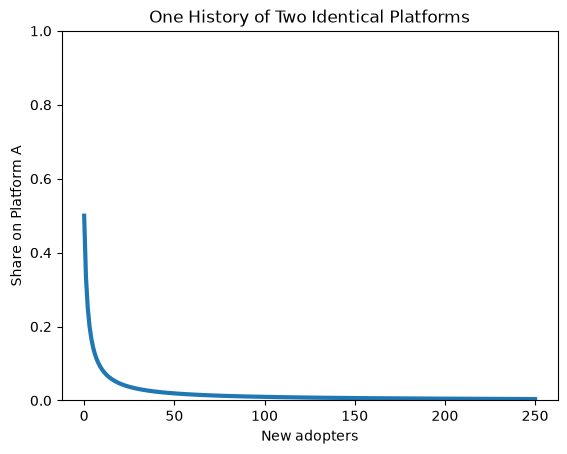

In [6]:
rng = np.random.default_rng(6318)
T = 250
one_path = reinforced_adoption(T, rng)

fig, ax = plt.subplots()
ax.plot(range(T + 1), one_path, linewidth=3, label="A share")
ax.set_xlabel("New adopters")
ax.set_ylabel("Share on Platform A")
ax.set_ylim(0, 1)
ax.set_title("One History of Two Identical Platforms")
plt.show()

### One History Is Not a Result

- That curve feels like a story about Platform A
- But A and B have exactly the same quality
- Change the random seed and the story may reverse
- Recall from week 6: an ABM describes a distribution over outcomes
- Let us run 200 possible histories

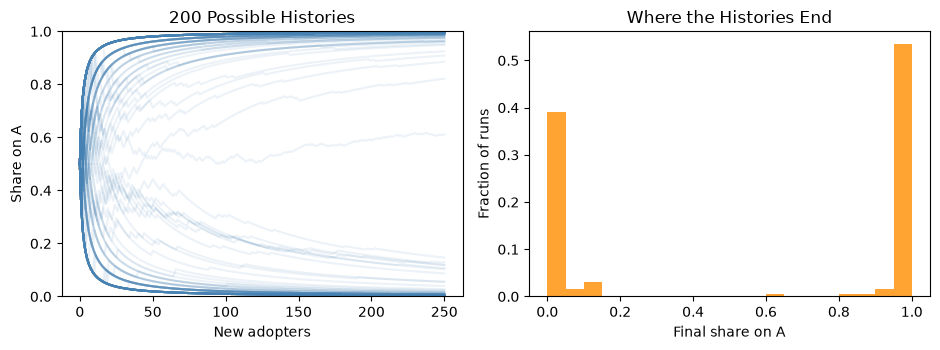

In [7]:
rng = np.random.default_rng(631802)
n_runs = 200
paths = np.column_stack([reinforced_adoption(T, rng) for _ in range(n_runs)])
final_shares = paths[-1, :]

fig, (ax_traj, ax_hist) = plt.subplots(1, 2, figsize=(9.5, 3.6))

ax_traj.plot(range(T + 1), paths, color="steelblue", alpha=0.10)
ax_traj.set_xlabel("New adopters")
ax_traj.set_ylabel("Share on A")
ax_traj.set_ylim(0, 1)
ax_traj.set_title("200 Possible Histories")

ax_hist.hist(final_shares, bins=np.arange(0, 1.05, 0.05), weights=np.full(n_runs, 1 / n_runs),
             color="darkorange", alpha=0.8)
ax_hist.set_xlabel("Final share on A")
ax_hist.set_ylabel("Fraction of runs")
ax_hist.set_title("Where the Histories End")

plt.tight_layout()
plt.show()

In [8]:
lock_in_rate = np.mean((final_shares <= 0.10) | (final_shares >= 0.90))
{"lock_in_rate": lock_in_rate, "A_wins": np.mean(final_shares > 0.5)}

{'lock_in_rate': np.float64(0.955), 'A_wins': np.float64(0.565)}

## Reveal: Lock-In without a Quality Difference

- Nearly every strongly reinforced run ends near 0 or 1
- This is **tipping**: positive feedback pushes the market toward one dominant platform
- But which platform wins is early random luck, not quality
- That sensitivity to history is **path dependence**
- Lock-in means later adopters rationally follow a lead created by earlier accidents
- Important qualification: the linear case $\gamma=1$ is path dependent, but its final shares need not be winner-take-all
- Winner-take-all is a result to explain, not a slogan to assume

### Emergence, Again

- As with segregation in week 6, a stark aggregate outcome emerges that no individual chose
- Each adopter makes a locally sensible choice
- Collectively, those choices can make one platform almost unavoidable
- Sidecar entered ride-hailing early, but Uber's growing driver-rider network helped pull later adoption toward Uber
- The model does not claim quality never matters
- It shows why timing and early scale can matter even when quality is equal

### Exercise 2: What Breaks Lock-In?

- Suppose users can multihome or move their data and contacts between platforms. Which change weakens lock-in more, and why?
- Now give the smaller platform a clear quality advantage. How large must that gap feel before early market share stops deciding the winner?
- Predict what happens to the dispersion of final market shares as the reinforcement exponent falls below 1

## Build 3: Networks Matter

- The urn treats every adopter as if they observe the whole market
- Real adoption often arrives through neighbors
- Recall cascades from our graph lectures
- An agent adopts when enough of their neighbors have adopted
- Does critical mass depend only on the number of seeds?

In [9]:
rng = np.random.default_rng(1202)
n = 120
g_er = nx.erdos_renyi_graph(n, 0.05, seed=rng)
g_ws = nx.watts_strogatz_graph(n, 6, 0.08, seed=rng)

{
    "erdos_renyi": {
        "edges": g_er.number_of_edges(),
        "mean_degree": np.mean([d for _, d in g_er.degree()]),
    },
    "watts_strogatz": {
        "edges": g_ws.number_of_edges(),
        "mean_degree": np.mean([d for _, d in g_ws.degree()]),
    },
}

{'erdos_renyi': {'edges': 350, 'mean_degree': np.float64(5.833333333333333)},
 'watts_strogatz': {'edges': 360, 'mean_degree': np.float64(6.0)}}

### A Threshold Rule

- Each node is either adopted or not adopted
- Seeds adopt at time 0
- Everyone else adopts when at least a fraction $\tau$ of their neighbors has adopted

$$
a_i(t+1) = 1 \quad \text{if} \quad \frac{\sum_{j \in N(i)} a_j(t)}{|N(i)|} \ge \tau.
$$

- Updates are synchronous: everyone responds to the previous round
- Adoption is irreversible in this simple model

In [10]:
def threshold_adoption(g, seeds, tau, max_steps=40):
    adopted = np.zeros(g.number_of_nodes(), dtype=bool)
    adopted[list(seeds)] = True
    adoption_rate = [adopted.mean()]

    for _ in range(max_steps):
        next_adopted = adopted.copy()
        for v in g.nodes():
            if not adopted[v]:
                nbrs = list(g.neighbors(v))
                if nbrs and adopted[nbrs].mean() >= tau:
                    next_adopted[v] = True

        if np.array_equal(next_adopted, adopted):
            break
        adopted = next_adopted
        adoption_rate.append(adopted.mean())

    return np.array(adoption_rate)

### Random or Targeted Seeding?

- We have a budget of five seeds
- Strategy 1: choose five nodes at random
- Strategy 2: target high-degree nodes
- On the Watts-Strogatz graph, we also keep targeted seeds locally concentrated
  - Local reinforcement matters when adoption uses a fractional threshold
- We compare the same seed budget and the same threshold across topologies

In [11]:
rng = np.random.default_rng(12025)
random_seeds = np.sort(rng.choice(n, size=5, replace=False))
er_degrees = np.array([d for _, d in sorted(g_er.degree())])
ws_degrees = np.array([d for _, d in sorted(g_ws.degree())])
er_targeted = np.sort(np.argsort(-er_degrees)[:5])

# Choose the highest-degree block of five nearby nodes on the WS ring.
ws_windows = [[(start + offset) % n for offset in range(5)] for start in range(n)]
ws_targeted = np.array(ws_windows[np.argmax([ws_degrees[w].sum() for w in ws_windows])])

{"random": random_seeds, "er_targeted": er_targeted, "ws_targeted": ws_targeted}

{'random': array([ 9, 11, 12, 56, 91]),
 'er_targeted': array([  8,  44,  82, 105, 112]),
 'ws_targeted': array([62, 63, 64, 65, 66])}

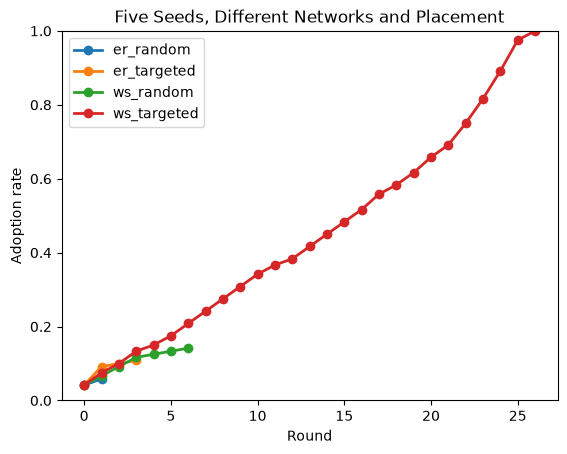

In [12]:
tau = 0.30
curves = {
    "er_random": threshold_adoption(g_er, random_seeds, tau),
    "er_targeted": threshold_adoption(g_er, er_targeted, tau),
    "ws_random": threshold_adoption(g_ws, random_seeds, tau),
    "ws_targeted": threshold_adoption(g_ws, ws_targeted, tau),
}

fig, ax = plt.subplots()
ax.set_xlabel("Round")
ax.set_ylabel("Adoption rate")
ax.set_ylim(0, 1)
ax.set_title("Five Seeds, Different Networks and Placement")
for label, curve in curves.items():
    ax.plot(range(len(curve)), curve, marker="o", linewidth=2, label=label)
ax.legend(loc="best")
plt.show()

## Reveal: Critical Mass Has a Shape

- Five seeds are not simply five seeds
- Their location determines how much local reinforcement they create
- Erdős-Rényi links scatter influence differently from clustered Watts-Strogatz links
- The same random seed identities can therefore produce different paths across the two graphs
- Targeting high-degree nodes expands reach; concentrating seeds can help neighbors cross a fractional threshold
- **Tipping** occurs when one round creates enough adopters to trigger the next
- Topology changes where critical mass lies

### A Warning about Influence

- High degree does not automatically mean easy to persuade
- A high-degree node may require many adopting neighbors to reach the same fractional threshold
- Seeding a hub can be powerful because many others observe it
- Waiting for a hub to adopt can be difficult because the hub observes many others
- Network interventions must distinguish outgoing reach from incoming social proof

## When Winner-Take-All Does Not Apply

- **Multihoming** means participating on more than one platform
- Riders can install both Uber and Lyft
- Drivers can accept work from both
- Multihoming weakens the feedback that makes one platform exclusive
- Coexistence is more likely when switching is easy, differentiation matters, or network effects are local
- Strong network effects can create concentration without creating a single winner

### Craigslist and Local Network Effects

- Craigslist looks like one giant marketplace
- But a renter in Orlando gains little from apartment listings in Seattle
- A job seeker may care about one occupation and one city, not the whole site
- Competitors can unbundle a broad platform vertical by vertical
- The relevant network effect may live inside a category, geography, or community
- Before predicting winner-take-all, ask: *which network is actually reinforcing which choice?*

### Exercise 3: Give the Better Platform an Edge

- Let Platform A be 10% more attractive than B
- Set $\theta=1.1$ and choose A with probability proportional to $\theta n_A$ versus $n_B$
- Run 500 simulations
- How often does the better platform finish with less than half the market?
- Interpret a loss: does it prove that quality is irrelevant?

In [13]:
def better_platform_loss_rate(theta=1.1, runs=500, T=250, rng=None):
    # TODO: repeat the adoption simulation `runs` times.
    # TODO: in each period use pA = theta * nA / (theta * nA + nB).
    # TODO: return the fraction of runs in which final nA < nB.
    return None


# TODO: set a seed, call the function, and explain the result.
better_platform_loss_rate()

### Exercise 4: Where Do Cascades Die?

- Use the Watts-Strogatz graph and the five targeted seeds
- Vary $\tau \in \{0.1, 0.3, 0.5\}$
- Plot all three adoption curves
- For which thresholds does the cascade reach most of the graph?
- Identify the first round in which each failed cascade stops growing

In [14]:
taus = [0.1, 0.3, 0.5]

# TODO: call threshold_adoption(g_ws, ws_targeted, tau) for each tau.
# TODO: plot the three curves and report where cascades die.
None

## What We Learned

- The chicken-and-egg problem is a coordination problem with a good and a bad equilibrium
- Subsidizing one side can select the good equilibrium by changing best responses
- Increasing returns can create tipping, lock-in, and path dependence
- Network topology and seed placement determine whether local adoption crosses critical mass
- Multihoming and local network effects limit winner-take-all predictions
- We have moved from same-side and cross-side network effects to ignition
- Soon we will study **stable matching** and the **blocking pair** that can unravel a proposed match

## Next Time

- Platforms must often subsidize a side to ignite
- But **which** side, and by how much?
- Is the important object the total price level or the price structure across sides?
- Next time, in L12.01, we make the pricing decision precise